In [1]:
import os
import copy
import time
import random
import hashlib
import numpy as np
import matplotlib.pyplot as plt
import cv2

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split, WeightedRandomSampler
from torch.optim.lr_scheduler import CosineAnnealingLR
from torchvision import datasets, transforms, models
from torchvision.models import DenseNet121_Weights
from PIL import Image

from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support
from pathlib import Path
import gc

In [2]:
# ============================================================
# 1. AYARLAR
# ============================================================
IMG_SIZE   = 224
BATCH_SIZE = 16
EPOCHS     = 100
SEED       = 42
LR         = 0.0005
VAL_SPLIT  = 0.15


TRAIN_DIR = r"C:\Users\nsynk\Downloads\archive\train"
TEST_DIR  = r"C:\Users\nsynk\Downloads\archive\test"

MODEL_SAVE_PATH  = "best_densenet121_model.pth"
PROBS_SAVE_PATH  = "probabilities_densenet121.npy"
LABELS_SAVE_PATH = "test_labels_densenet121.npy"
CM_SAVE_PATH     = "confusion_matrix_densenet121.jpg"

ROI_CACHE_DIR = r"C:\Users\nsynk\Downloads\archive\roi_cache"

# Hedef sınıflar
TARGET_CLASSES = [
    "Acne and Rosacea Photos",
    "Eczema Photos",
    "Psoriasis pictures Lichen Planus and related diseases",
    "Urticaria Hives",
    "Nail Fungus and other Nail Disease",
    "Scabies Lyme Disease and other Infestations and Bites",
]

print("Model: DenseNet121 (v5)")
print(f"Batch size: {BATCH_SIZE}")
print(f"Learning Rate: {LR}")
print(f"Hedef sınıf sayısı: {len(TARGET_CLASSES)}")

Model: DenseNet121 (v5)
Batch size: 16
Learning Rate: 0.0005
Hedef sınıf sayısı: 6


In [3]:
# ============================================================
# 2. SEED
# ============================================================
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.benchmark = False
        torch.backends.cudnn.deterministic = True

set_seed(SEED)

In [4]:
# ============================================================
# 3. DEVICE (CUDA / CPU)
# ============================================================
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"Kullanılan cihaz: CUDA - {torch.cuda.get_device_name(0)}")
    free, total = torch.cuda.mem_get_info(0)
    print(f"VRAM: {total / 1024**3:.1f} GB")
else:
    device = torch.device("cpu")
    print("⚠️ CUDA bulunamadı! CPU kullanılacak.")

Kullanılan cihaz: CUDA - NVIDIA GeForce RTX 3050 Ti Laptop GPU
VRAM: 4.0 GB


In [5]:
# ============================================================
# 4. PATH KONTROL
# Hedef sınıf klasörlerinin varlığı kontrol ediliyor.
# ============================================================
print("Train yolu var mı:", os.path.exists(TRAIN_DIR))
print("Test yolu var mı :", os.path.exists(TEST_DIR))

if not os.path.exists(TRAIN_DIR) or not os.path.exists(TEST_DIR):
    print("\n⚠️  Dosya yolları bulunamadı!")
    print("TRAIN_DIR ve TEST_DIR değişkenlerini düzenle.")
    print(f"Şu an aranan: {TRAIN_DIR}")
    print('\nÖrnek: r"C:\\Users\\Mehmet\\Downloads\\archive\\train"')
else:
    # Hedef sınıf klasörlerini kontrol et
    print("\nHedef sınıf kontrolü:")
    for cls in TARGET_CLASSES:
        train_path = os.path.join(TRAIN_DIR, cls)
        test_path = os.path.join(TEST_DIR, cls)
        train_ok = os.path.exists(train_path)
        test_ok = os.path.exists(test_path)
        status = "✅" if (train_ok and test_ok) else "❌"
        print(f"  {status} {cls}")
        if not train_ok:
            print(f"      ⚠️ Train klasörü bulunamadı: {train_path}")
        if not test_ok:
            print(f"      ⚠️ Test klasörü bulunamadı: {test_path}")

Train yolu var mı: True
Test yolu var mı : True

Hedef sınıf kontrolü:
  ✅ Acne and Rosacea Photos
  ✅ Eczema Photos
  ✅ Psoriasis pictures Lichen Planus and related diseases
  ✅ Urticaria Hives
  ✅ Nail Fungus and other Nail Disease
  ✅ Scabies Lyme Disease and other Infestations and Bites


In [6]:
# ============================================================
# 5. ROI (Region of Interest) FONKSİYONU
# ============================================================
def extract_roi(image_path, target_size=224):
    """
    Görüntüden lezyon bölgesini (ROI) otomatik tespit eder ve kırpar.
    """
    img = cv2.imread(image_path)
    if img is None:
        return None

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (11, 11), 0)

    _, thresh = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    thresh = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel, iterations=3)
    thresh = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=2)

    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if contours:
        largest = max(contours, key=cv2.contourArea)
        area = cv2.contourArea(largest)
        img_area = img.shape[0] * img.shape[1]

        if area < img_area * 0.01 or area > img_area * 0.95:
            roi = img_rgb
        else:
            x, y, w, h = cv2.boundingRect(largest)
            pad_w = int(w * 0.15)
            pad_h = int(h * 0.15)
            x1 = max(0, x - pad_w)
            y1 = max(0, y - pad_h)
            x2 = min(img.shape[1], x + w + pad_w)
            y2 = min(img.shape[0], y + h + pad_h)
            roi = img_rgb[y1:y2, x1:x2]
    else:
        roi = img_rgb

    roi = cv2.resize(roi, (target_size, target_size))
    return roi

In [7]:
# ============================================================
# 5.5 ROI ÖNBELLEK FONKSİYONU
# ============================================================
def get_cached_roi(image_path, target_size=224):
    cache_dir = Path(ROI_CACHE_DIR)
    cache_dir.mkdir(parents=True, exist_ok=True)

    key = hashlib.md5(image_path.encode()).hexdigest()
    cache_path = cache_dir / f"{key}.npy"

    if cache_path.exists():
        return np.load(cache_path)

    roi = extract_roi(image_path, target_size)
    if roi is not None:
        np.save(cache_path, roi)
    return roi

print(f"ROI önbellek klasörü: {ROI_CACHE_DIR}")

ROI önbellek klasörü: C:\Users\nsynk\Downloads\archive\roi_cache


In [8]:
# ============================================================
# 6. ROI DATASET SINIFI.
# ============================================================
class ROIDataset(Dataset):
    def __init__(self, root_dir, transform=None, target_size=224,
                 use_cache=True, target_classes=None):
        self.root_dir = root_dir
        self.transform = transform
        self.target_size = target_size
        self.use_cache = use_cache
        self.roi_fail_count = 0
        self.total_loaded = 0

        # Sadece hedef sınıfları yükle (verilmezse tüm klasörleri yükle)
        if target_classes is not None:
            self.classes = sorted([
                d for d in target_classes
                if os.path.isdir(os.path.join(root_dir, d))
            ])
        else:
            self.classes = sorted([
                d for d in os.listdir(root_dir)
                if os.path.isdir(os.path.join(root_dir, d))
            ])

        self.class_to_idx = {cls: idx for idx, cls in enumerate(self.classes)}

        self.samples = []
        for cls in self.classes:
            cls_dir = os.path.join(root_dir, cls)
            for fname in os.listdir(cls_dir):
                fpath = os.path.join(cls_dir, fname)
                if os.path.isfile(fpath):
                    self.samples.append((fpath, self.class_to_idx[cls]))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        self.total_loaded += 1

        if self.use_cache:
            roi = get_cached_roi(img_path, self.target_size)
        else:
            roi = extract_roi(img_path, self.target_size)

        if roi is None:
            self.roi_fail_count += 1
            print(f"⚠️ ROI başarısız: {img_path}")
            roi = cv2.imread(img_path)
            if roi is not None:
                roi = cv2.cvtColor(roi, cv2.COLOR_BGR2RGB)
                roi = cv2.resize(roi, (self.target_size, self.target_size))
            else:
                roi = np.zeros((self.target_size, self.target_size, 3), dtype=np.uint8)

        pil_img = Image.fromarray(roi)

        if self.transform:
            pil_img = self.transform(pil_img)

        return pil_img, label

In [9]:
# ============================================================
# 6.5 TRANSFORM WRAPPER
# ============================================================
class TransformSubset(Dataset):
    def __init__(self, subset, transform):
        self.subset = subset
        self.transform = transform

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, idx):
        pil_img, label = self.subset[idx]
        if self.transform:
            pil_img = self.transform(pil_img)
        return pil_img, label

In [10]:
# ============================================================
# 7. TRANSFORMS
# ============================================================
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomAffine(degrees=0, shear=10),
    transforms.ColorJitter(
        brightness=0.2, contrast=0.2,
        saturation=0.15, hue=0.05
    ),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

eval_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

In [11]:
# ============================================================
# 8. DATASET YÜKLEME
# ============================================================
NUM_WORKERS = 0

print("Train verileri ROI ile yükleniyor (sadece hedef sınıflar)...")
full_train_dataset = ROIDataset(
    TRAIN_DIR, transform=None, target_size=IMG_SIZE,
    target_classes=TARGET_CLASSES
)
class_names = full_train_dataset.classes
NUM_CLASSES = len(class_names)

print(f"Sınıf sayısı: {NUM_CLASSES}")
print(f"Sınıflar: {class_names}")

print("\nSınıf dağılımı:")
for cls in class_names:
    count = sum(1 for _, label in full_train_dataset.samples
                if full_train_dataset.classes[label] == cls)
    print(f"  {cls}: {count} görüntü")

# Train / Val split
train_size = int((1 - VAL_SPLIT) * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size

train_subset, val_subset = random_split(
    full_train_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED)
)

train_dataset = TransformSubset(train_subset, train_transform)
val_dataset = TransformSubset(val_subset, eval_transform)

# [v5] Oversampling — az örnekli sınıflar daha sık çekilir
train_labels = [full_train_dataset.samples[i][1] for i in train_subset.indices]
class_sample_counts = np.bincount(train_labels)
weights_per_class = 1.0 / class_sample_counts
sample_weights = [weights_per_class[label] for label in train_labels]
sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

print("\nOversampling ağırlıkları:")
for i, cls in enumerate(class_names):
    print(f"  {cls}: {weights_per_class[i]:.4f} (n={class_sample_counts[i]})")

print("\nTest verileri ROI ile yükleniyor (sadece hedef sınıflar)...")
test_dataset = ROIDataset(
    TEST_DIR, transform=eval_transform, target_size=IMG_SIZE,
    target_classes=TARGET_CLASSES
)

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=False,
    sampler=sampler, num_workers=0, pin_memory=True
)

val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=0, pin_memory=True
)

test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=0, pin_memory=True
)

print(f"\nTrain: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

Train verileri ROI ile yükleniyor (sadece hedef sınıflar)...
Sınıf sayısı: 6
Sınıflar: ['Acne and Rosacea Photos', 'Eczema Photos', 'Nail Fungus and other Nail Disease', 'Psoriasis pictures Lichen Planus and related diseases', 'Scabies Lyme Disease and other Infestations and Bites', 'Urticaria Hives']

Sınıf dağılımı:
  Acne and Rosacea Photos: 840 görüntü
  Eczema Photos: 1235 görüntü
  Nail Fungus and other Nail Disease: 1040 görüntü
  Psoriasis pictures Lichen Planus and related diseases: 1405 görüntü
  Scabies Lyme Disease and other Infestations and Bites: 431 görüntü
  Urticaria Hives: 212 görüntü

Oversampling ağırlıkları:
  Acne and Rosacea Photos: 0.0014 (n=728)
  Eczema Photos: 0.0010 (n=1023)
  Nail Fungus and other Nail Disease: 0.0011 (n=884)
  Psoriasis pictures Lichen Planus and related diseases: 0.0008 (n=1195)
  Scabies Lyme Disease and other Infestations and Bites: 0.0028 (n=362)
  Urticaria Hives: 0.0051 (n=196)

Test verileri ROI ile yükleniyor (sadece hedef sınıflar

In [12]:
# ============================================================
# 9. CLASS WEIGHTS
# ============================================================
labels_all = [label for _, label in full_train_dataset.samples]
class_counts = np.bincount(labels_all)
total_samples = len(labels_all)

class_weights = total_samples / (NUM_CLASSES * class_counts)
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)

print("Class weights:")
for i, cls in enumerate(class_names):
    print(f"  {cls}: {class_weights[i]:.3f} (n={class_counts[i]})")

Class weights:
  Acne and Rosacea Photos: 1.024 (n=840)
  Eczema Photos: 0.697 (n=1235)
  Nail Fungus and other Nail Disease: 0.827 (n=1040)
  Psoriasis pictures Lichen Planus and related diseases: 0.612 (n=1405)
  Scabies Lyme Disease and other Infestations and Bites: 1.997 (n=431)
  Urticaria Hives: 4.059 (n=212)


In [13]:
# ============================================================
# 10. MODEL (DenseNet121)
# ============================================================
model = models.densenet121(weights=DenseNet121_Weights.DEFAULT)

# Aşama 1: Tüm backbone donuk
for param in model.features.parameters():
    param.requires_grad = False

# [v5] Classifier head — BatchNorm eklendi
in_features = model.classifier.in_features  # 1024
model.classifier = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(in_features, 512),
    nn.BatchNorm1d(512),
    nn.ReLU(),
    nn.Dropout(0.2),
    nn.Linear(512, NUM_CLASSES)
)

model = model.to(device)

# [v5] Label smoothing — model %100 emin olmayı öğrenmez, genelleme artar
criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)

# [v5] AdamW — weight_decay ile regularization
optimizer = optim.AdamW(model.classifier.parameters(), lr=LR, weight_decay=1e-4)

# [v5] CosineAnnealingLR — LR'yi yumuşak eğriyle düşürür
scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters())
print(f"DenseNet121 hazır (v5). Sınıf sayısı: {NUM_CLASSES}")
print(f"Toplam parametre: {total_params:,}")
print(f"Eğitilebilir (Aşama 1): {trainable:,}")
print(f"LR: {LR} | Optimizer: AdamW | Label Smoothing: 0.1")
if device.type == "cuda":
    print(f"VRAM kullanımı: {torch.cuda.memory_allocated()/1024**2:.0f} MB")

DenseNet121 hazır (v5). Sınıf sayısı: 6
Toplam parametre: 7,482,758
Eğitilebilir (Aşama 1): 528,902
LR: 0.0005 | Optimizer: AdamW | Label Smoothing: 0.1
VRAM kullanımı: 29 MB


In [14]:
# ============================================================
# 11. EĞİTİM / DEĞERLENDİRME FONKSİYONLARI
# ============================================================
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total


def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_labels = []
    all_preds = []
    all_probs = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    precision, recall, f1, _ = precision_recall_fscore_support(
        all_labels, all_preds, average="macro", zero_division=0
    )

    return (epoch_loss, epoch_acc, precision, recall, f1,
            np.array(all_labels), np.array(all_preds), np.array(all_probs))

In [15]:
# ============================================================
# 12. AŞAMA 1: CLASSIFIER EĞİTİMİ
# ============================================================
print("=" * 50)
print("AŞAMA 1: CLASSIFIER EĞİTİMİ (Backbone donuk)")
print(f"Sınıf sayısı: {NUM_CLASSES} | LR: {LR}")
print("=" * 50)

best_val_acc = 0.0
best_model_wts = copy.deepcopy(model.state_dict())
early_stop_patience = 15
epochs_no_improve = 0

start_time = time.time()

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    print("-" * 45)

    train_loss, train_acc = train_one_epoch(
        model, train_loader, criterion, optimizer, device
    )

    val_loss, val_acc, val_prec, val_rec, val_f1, _, _, _ = evaluate(
        model, val_loader, criterion, device
    )

    # [v5] CosineAnnealingLR — parametre gerektirmez
    scheduler.step()

    current_lr = optimizer.param_groups[0]["lr"]
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f}")
    print(f"Val Precision: {val_prec:.4f} | Val Recall: {val_rec:.4f} | Val F1: {val_f1:.4f}")
    print(f"LR: {current_lr:.6f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_wts = copy.deepcopy(model.state_dict())
        torch.save(model.state_dict(), MODEL_SAVE_PATH)
        print(f"En iyi model kaydedildi -> {MODEL_SAVE_PATH}")
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        print(f"İyileşme yok ({epochs_no_improve}/{early_stop_patience})")

    if epochs_no_improve >= early_stop_patience:
        print(f"\nEarly stopping! {early_stop_patience} epoch boyunca iyileşme olmadı.")
        break

    if device.type == "cuda" and (epoch + 1) % 10 == 0:
        torch.cuda.empty_cache()
        gc.collect()

elapsed = time.time() - start_time
print(f"\nAşama 1 tamamlandı. Süre: {elapsed/60:.2f} dakika")

AŞAMA 1: CLASSIFIER EĞİTİMİ (Backbone donuk)
Sınıf sayısı: 6 | LR: 0.0005

Epoch 1/100
---------------------------------------------
Train Loss: 1.2806 | Train Acc: 0.4175
Val   Loss: 1.5423 | Val   Acc: 0.4413
Val Precision: 0.4910 | Val Recall: 0.5760 | Val F1: 0.4259
LR: 0.000500
En iyi model kaydedildi -> best_densenet121_model.pth

Epoch 2/100
---------------------------------------------
Train Loss: 1.2180 | Train Acc: 0.4660
Val   Loss: 1.5247 | Val   Acc: 0.4658
Val Precision: 0.5073 | Val Recall: 0.5797 | Val F1: 0.4405
LR: 0.000500
En iyi model kaydedildi -> best_densenet121_model.pth

Epoch 3/100
---------------------------------------------
Train Loss: 1.1530 | Train Acc: 0.4989
Val   Loss: 1.5827 | Val   Acc: 0.4258
Val Precision: 0.4913 | Val Recall: 0.5569 | Val F1: 0.4057
LR: 0.000499
İyileşme yok (1/15)

Epoch 4/100
---------------------------------------------
Train Loss: 1.1756 | Train Acc: 0.4861
Val   Loss: 1.5005 | Val   Acc: 0.4800
Val Precision: 0.4994 | Val Rec

In [16]:
# ============================================================
# 13. EN İYİ MODELİ YÜKLE + AŞAMA 1 SONUÇLARI
# ============================================================
model.load_state_dict(best_model_wts)

test_criterion = nn.CrossEntropyLoss(weight=class_weights)
phase1_loss, phase1_acc, phase1_prec, phase1_rec, phase1_f1, _, _, _ = evaluate(
    model, test_loader, test_criterion, device
)

print("=" * 50)
print("AŞAMA 1 SONUÇLARI (Sadece Classifier)")
print("=" * 50)
print(f"Test Loss      : {phase1_loss:.4f}")
print(f"Test Accuracy  : {phase1_acc:.4f}")
print(f"Test Precision : {phase1_prec:.4f}")
print(f"Test Recall    : {phase1_rec:.4f}")
print(f"Test F1 Score  : {phase1_f1:.4f}")
print("=" * 50)

AŞAMA 1 SONUÇLARI (Sadece Classifier)
Test Loss      : 1.0838
Test Accuracy  : 0.6065
Test Precision : 0.5930
Test Recall    : 0.6639
Test F1 Score  : 0.5621


In [17]:
# ============================================================
# 14. AŞAMA 2: FINE-TUNING
# ============================================================
print("\n" + "=" * 50)
print("AŞAMA 2: FINE-TUNING BAŞLIYOR")
print("=" * 50)

for name, param in model.features.named_parameters():
    if any(x in name for x in ["denseblock3", "transition3", "denseblock4", "norm5"]):
        param.requires_grad = True

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters())
print(f"Eğitilebilir parametre: {trainable:,} / {total_params:,} ({100*trainable/total_params:.1f}%)")

FINE_TUNE_LR = 0.0001

backbone_params = []
classifier_params = []
for name, param in model.named_parameters():
    if param.requires_grad:
        if "classifier" in name:
            classifier_params.append(param)
        else:
            backbone_params.append(param)

# [v5] AdamW + discriminative LR
optimizer_ft = optim.AdamW([
    {"params": backbone_params,    "lr": FINE_TUNE_LR / 5},    # 2e-5
    {"params": classifier_params,  "lr": FINE_TUNE_LR}          # 1e-4
], weight_decay=1e-4)

FT_EPOCHS = 80
FT_PATIENCE = 12

# [v5] CosineAnnealingLR
scheduler_ft = CosineAnnealingLR(optimizer_ft, T_max=FT_EPOCHS, eta_min=1e-7)

print(f"Backbone LR: {FINE_TUNE_LR/5} | Classifier LR: {FINE_TUNE_LR}")
print(f"Optimizer: AdamW | Scheduler: CosineAnnealingLR")
print(f"Epochs: {FT_EPOCHS} | Patience: {FT_PATIENCE}")
if device.type == "cuda":
    print(f"VRAM kullanımı: {torch.cuda.memory_allocated()/1024**2:.0f} MB")


AŞAMA 2: FINE-TUNING BAŞLIYOR
Eğitilebilir parametre: 6,053,126 / 7,482,758 (80.9%)
Backbone LR: 2e-05 | Classifier LR: 0.0001
Optimizer: AdamW | Scheduler: CosineAnnealingLR
Epochs: 80 | Patience: 12
VRAM kullanımı: 80 MB


In [18]:
# ============================================================
# 15. FINE-TUNING EĞİTİM DÖNGÜSÜ
# ============================================================
best_ft_acc = phase1_acc
best_ft_wts = copy.deepcopy(model.state_dict())
ft_no_improve = 0

ft_start = time.time()

for epoch in range(FT_EPOCHS):
    print(f"\n[Fine-Tune] Epoch {epoch+1}/{FT_EPOCHS}")
    print("-" * 45)

    train_loss, train_acc = train_one_epoch(
        model, train_loader, criterion, optimizer_ft, device
    )

    val_loss, val_acc, val_prec, val_rec, val_f1, _, _, _ = evaluate(
        model, val_loader, criterion, device
    )

    # [v5] CosineAnnealingLR
    scheduler_ft.step()

    current_lr = optimizer_ft.param_groups[0]["lr"]
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f}")
    print(f"Val F1: {val_f1:.4f} | LR: {current_lr:.8f}")

    if val_acc > best_ft_acc:
        best_ft_acc = val_acc
        best_ft_wts = copy.deepcopy(model.state_dict())
        torch.save(model.state_dict(), "best_densenet121_finetuned.pth")
        print(f"Fine-tuned model kaydedildi! (Acc: {val_acc:.4f})")
        ft_no_improve = 0
    else:
        ft_no_improve += 1
        print(f"İyileşme yok ({ft_no_improve}/{FT_PATIENCE})")

    if ft_no_improve >= FT_PATIENCE:
        print(f"\nFine-tuning early stopping! {FT_PATIENCE} epoch iyileşme olmadı.")
        break

    if device.type == "cuda" and (epoch + 1) % 10 == 0:
        torch.cuda.empty_cache()
        gc.collect()

ft_elapsed = time.time() - ft_start
print(f"\nFine-tuning tamamlandı. Süre: {ft_elapsed/60:.2f} dakika")


[Fine-Tune] Epoch 1/80
---------------------------------------------
Train Loss: 0.8994 | Train Acc: 0.6506
Val   Loss: 1.3843 | Val   Acc: 0.5910
Val F1: 0.5480 | LR: 0.00001999
İyileşme yok (1/12)

[Fine-Tune] Epoch 2/80
---------------------------------------------
Train Loss: 0.8807 | Train Acc: 0.6445
Val   Loss: 1.3880 | Val   Acc: 0.5897
Val F1: 0.5564 | LR: 0.00001997
İyileşme yok (2/12)

[Fine-Tune] Epoch 3/80
---------------------------------------------
Train Loss: 0.8369 | Train Acc: 0.6778
Val   Loss: 1.3714 | Val   Acc: 0.5845
Val F1: 0.5449 | LR: 0.00001993
İyileşme yok (3/12)

[Fine-Tune] Epoch 4/80
---------------------------------------------
Train Loss: 0.8219 | Train Acc: 0.6944
Val   Loss: 1.3831 | Val   Acc: 0.5781
Val F1: 0.5415 | LR: 0.00001988
İyileşme yok (4/12)

[Fine-Tune] Epoch 5/80
---------------------------------------------
Train Loss: 0.8152 | Train Acc: 0.6898
Val   Loss: 1.3557 | Val   Acc: 0.6129
Val F1: 0.5714 | LR: 0.00001981
Fine-tuned model kay

In [19]:
# ============================================================
# 16. FINE-TUNED MODELİ YÜKLE + TEST
# ============================================================
model.load_state_dict(best_ft_wts)

test_criterion = nn.CrossEntropyLoss(weight=class_weights)
test_loss, test_acc, test_prec, test_rec, test_f1, y_true, y_pred, y_probs = evaluate(
    model, test_loader, test_criterion, device
)

print("\n" + "=" * 50)
print("AŞAMA 2 TEST SONUÇLARI (DenseNet121 Fine-Tuned)")
print(f"Sınıf sayısı: {NUM_CLASSES}")
print("=" * 50)
print(f"Test Loss      : {test_loss:.4f}")
print(f"Test Accuracy  : {test_acc:.4f}")
print(f"Test Precision : {test_prec:.4f}")
print(f"Test Recall    : {test_rec:.4f}")
print(f"Test F1 Score  : {test_f1:.4f}")
print("=" * 50)

print(f"\n--- KARŞILAŞTIRMA ---")
print(f"Aşama 1 (Classifier only) Accuracy: {phase1_acc:.4f}")
print(f"Aşama 2 (Fine-tuned)      Accuracy: {test_acc:.4f}")
improvement = (test_acc - phase1_acc) * 100
print(f"İyileşme: {improvement:+.2f} puan")

if device.type == "cuda":
    print(f"\nMax VRAM kullanımı: {torch.cuda.max_memory_allocated()/1024**2:.0f} MB")


AŞAMA 2 TEST SONUÇLARI (DenseNet121 Fine-Tuned)
Sınıf sayısı: 6
Test Loss      : 0.7468
Test Accuracy  : 0.7570
Test Precision : 0.6991
Test Recall    : 0.7457
Test F1 Score  : 0.7110

--- KARŞILAŞTIRMA ---
Aşama 1 (Classifier only) Accuracy: 0.6065
Aşama 2 (Fine-tuned)      Accuracy: 0.7570
İyileşme: +15.05 puan

Max VRAM kullanımı: 737 MB


In [20]:
# ============================================================
# 17. CLASSIFICATION REPORT
# ============================================================
print("\nClassification Report (DenseNet121 Fine-Tuned):")
print(classification_report(
    y_true, y_pred,
    target_names=class_names,
    digits=3,
    zero_division=0
))


Classification Report (DenseNet121 Fine-Tuned):
                                                       precision    recall  f1-score   support

                              Acne and Rosacea Photos      0.819     0.984     0.894       312
                                        Eczema Photos      0.799     0.706     0.749       309
                   Nail Fungus and other Nail Disease      0.861     0.854     0.858       261
Psoriasis pictures Lichen Planus and related diseases      0.775     0.557     0.648       352
Scabies Lyme Disease and other Infestations and Bites      0.487     0.713     0.579       108
                                      Urticaria Hives      0.455     0.660     0.538        53

                                             accuracy                          0.757      1395
                                            macro avg      0.699     0.746     0.711      1395
                                         weighted avg      0.772     0.757     0.755      1395

In [21]:
# ============================================================
# 18. NPY DOSYALARINI KAYDET
# ============================================================
np.save(PROBS_SAVE_PATH, y_probs)
np.save(LABELS_SAVE_PATH, y_true)
print(f"Kaydedildi -> {PROBS_SAVE_PATH} | shape: {y_probs.shape}")
print(f"Kaydedildi -> {LABELS_SAVE_PATH} | shape: {y_true.shape}")

Kaydedildi -> probabilities_densenet121.npy | shape: (1395, 6)
Kaydedildi -> test_labels_densenet121.npy | shape: (1395,)


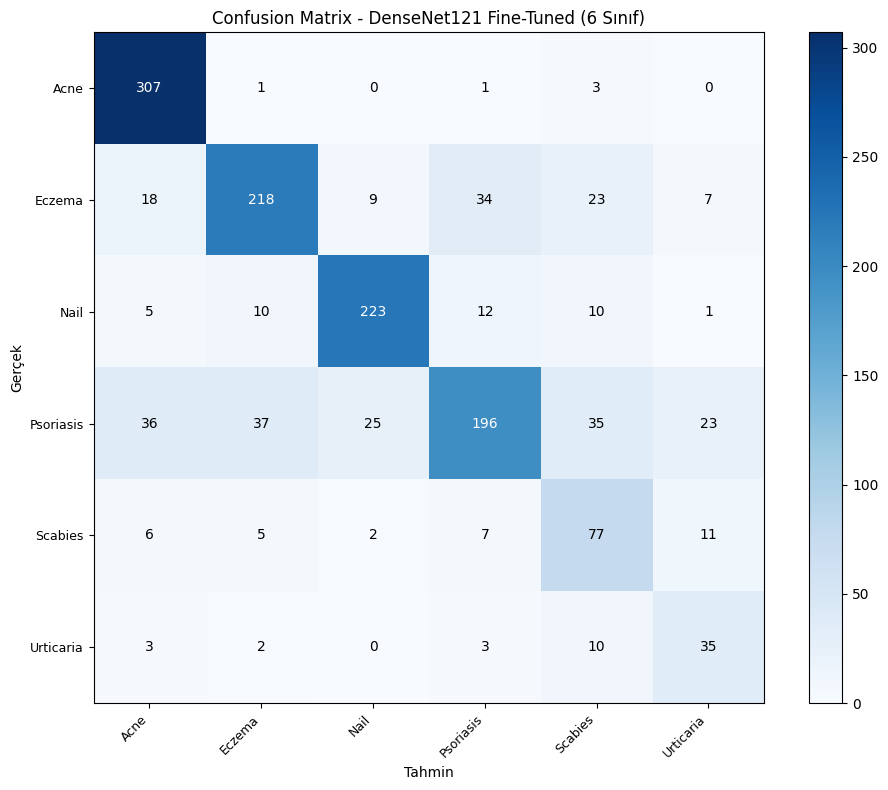

Kaydedildi -> confusion_matrix_densenet121.jpg


In [22]:
# ============================================================
# 19. CONFUSION MATRIX
# ============================================================
cm = confusion_matrix(y_true, y_pred)

# 6 sınıf için daha uygun figür boyutu
plt.figure(figsize=(10, 8))
plt.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
plt.title("Confusion Matrix - DenseNet121 Fine-Tuned (6 Sınıf)")
plt.colorbar()

# Kısa sınıf isimleri (görselde okunabilirlik için)
short_names = [c.split(" ")[0] for c in class_names]
plt.xticks(range(NUM_CLASSES), short_names, rotation=45, ha="right", fontsize=9)
plt.yticks(range(NUM_CLASSES), short_names, fontsize=9)

# Hücrelere sayı yaz
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        color = "white" if cm[i, j] > cm.max() / 2 else "black"
        plt.text(j, i, str(cm[i, j]), ha="center", va="center", color=color, fontsize=10)

plt.xlabel("Tahmin")
plt.ylabel("Gerçek")
plt.tight_layout()
plt.savefig(CM_SAVE_PATH, dpi=150, bbox_inches="tight")
plt.show()
print(f"Kaydedildi -> {CM_SAVE_PATH}")

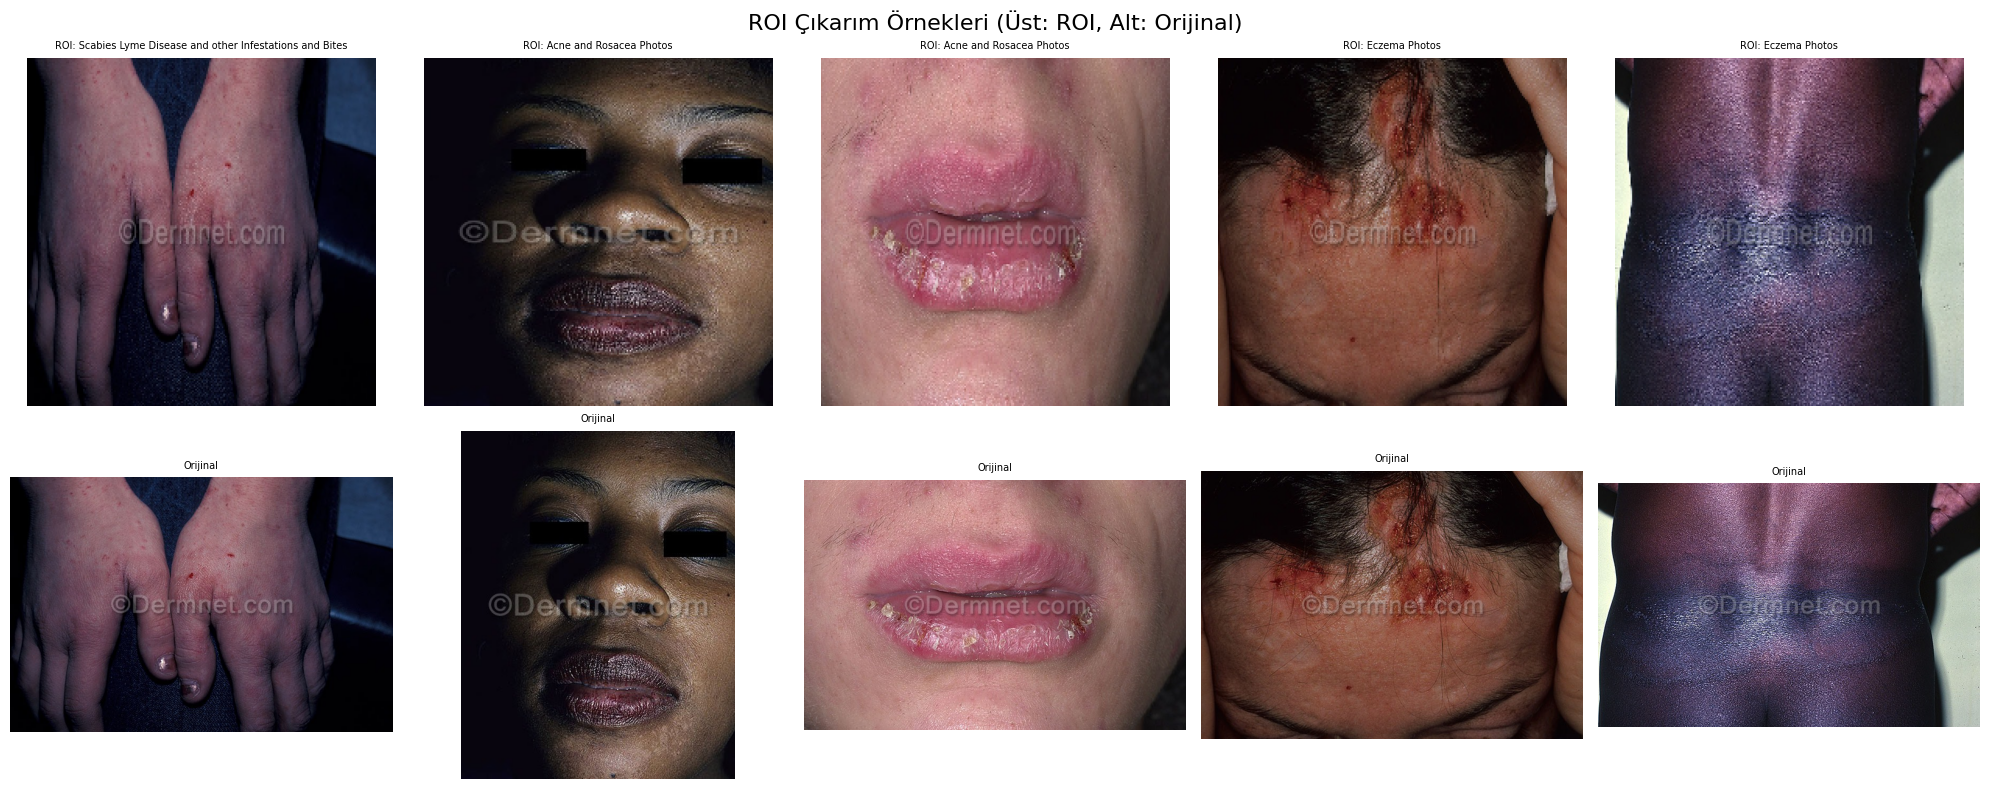

ROI örnek görseli kaydedildi!


In [23]:
# ============================================================
# 20. ROI ÖRNEK GÖRSELLEŞTİRME
# ============================================================
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
fig.suptitle("ROI Çıkarım Örnekleri (Üst: ROI, Alt: Orijinal)", fontsize=16)

sample_indices = random.sample(range(len(test_dataset)), 5)

for i, idx in enumerate(sample_indices):
    img_path, label = test_dataset.samples[idx]

    roi = extract_roi(img_path, IMG_SIZE)
    if roi is not None:
        axes[0, i].imshow(roi)
    axes[0, i].set_title(f"ROI: {class_names[label]}", fontsize=7)
    axes[0, i].axis("off")

    orig = cv2.imread(img_path)
    if orig is not None:
        orig = cv2.cvtColor(orig, cv2.COLOR_BGR2RGB)
        axes[1, i].imshow(orig)
    axes[1, i].set_title("Orijinal", fontsize=7)
    axes[1, i].axis("off")

plt.tight_layout()
plt.savefig("roi_examples.png", dpi=150, bbox_inches="tight")
plt.show()
print("ROI örnek görseli kaydedildi!")

In [24]:
# ============================================================
# 21. BİTTİ
# ============================================================
print("\nHer şey tamamlandı!")
print(f"Model: DenseNet121")
print(f"Sınıf sayısı: {NUM_CLASSES}")
print(f"Sınıflar: {class_names}")
print(f"Final Accuracy: {test_acc:.4f}")
print(f"Final F1 Score: {test_f1:.4f}")

if device.type == "cuda":
    print(f"Max VRAM: {torch.cuda.max_memory_allocated()/1024**2:.0f} MB")

cache_path = Path(ROI_CACHE_DIR)
if cache_path.exists():
    cache_files = list(cache_path.glob("*.npy"))
    total_mb = sum(f.stat().st_size for f in cache_files) / (1024 * 1024)
    print(f"ROI önbellek: {len(cache_files)} dosya, {total_mb:.1f} MB")


Her şey tamamlandı!
Model: DenseNet121
Sınıf sayısı: 6
Sınıflar: ['Acne and Rosacea Photos', 'Eczema Photos', 'Nail Fungus and other Nail Disease', 'Psoriasis pictures Lichen Planus and related diseases', 'Scabies Lyme Disease and other Infestations and Bites', 'Urticaria Hives']
Final Accuracy: 0.7570
Final F1 Score: 0.7110
Max VRAM: 737 MB
ROI önbellek: 6558 dosya, 942.2 MB


In [ ]:
# ============================================================
# 22. MODEL PERFORMANS GRAFİĞİ
# ============================================================
import matplotlib.pyplot as plt

metrics = {
    'Accuracy': 0.7570,
    'Precision': 0.6991,
    'Recall': 0.7457,
    'F1 Score': 0.7110,
}

print(f"Accuracy: {metrics['Accuracy']:.4f}")
print(f"Precision: {metrics['Precision']:.4f}")
print(f"Recall: {metrics['Recall']:.4f}")
print(f"F1 Score: {metrics['F1 Score']:.4f}")

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(metrics.keys(), metrics.values(), color='#1976D2', width=0.5)

for bar, val in zip(bars, metrics.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{val:.4f}", ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_ylim(0, 1.0)
ax.set_ylabel('Skor', fontsize=12)
ax.set_title('Model DenseNet121 Performance', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('model_performance_densenet121.jpg', dpi=150, bbox_inches='tight')
plt.show()